In [1]:
import re

import colorcet as cc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, MDS, TSNE


In [2]:
plt.rcParams.update({
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7
})

cm_to_inch = 1 / 2.54
figsize_cm = (8 * cm_to_inch, 8 * cm_to_inch)  # (9cm, 9cm)
fig_size = figsize_cm
fig_args = {"figsize":fig_size}
tick_args = {"pad":0}
lable_args = {"labelpad" : -5}
save_args = {"bbox_inches":'tight', "dpi":300}

In [3]:


def parse_gromos_cluster_log(filepath):
    """
    Parse a cluster.log file generated by the GROMOS clustering method.
    Extract the member indices for each cluster.
    
    Parameters:
        filepath (str): Path to the cluster.log file.
    
    Returns:
        dict: {cluster_id: [member_indices]}
    """
    clusters = {}
    current_cluster = None
    members = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.rstrip('\n')
            
            # Match a cluster header line, for example: '  1 | 1734  0.729 | 153400 .540 |  53400  53500 ...'
            header_match = re.match(r'^\s*(\d+)\s+\|', line)
            if header_match:
                # Save the previous cluster
                if current_cluster is not None:
                    clusters[current_cluster] = members
                
                # Start a new cluster
                current_cluster = int(header_match.group(1))
                # Extract the content after the last '|' in this line
                parts = line.split('|')
                if len(parts) >= 4:      # Format: cluster id | #st rmsd | middle rmsd | members
                    members_str = parts[3].strip()
                else:
                    members_str = ''
                # Extract all numbers
                members = [int(x) for x in re.findall(r'\d+', members_str)]
                continue
            
            # Match continuation lines that start with spaces plus '|' while a cluster is active
            if current_cluster is not None and re.match(r'^\s+\|', line):
                # The member list appears after the last '|' in continuation lines
                parts = line.split('|')
                if len(parts) >= 2:
                    members_str = parts[-1].strip()
                    numbers = [int(x) for x in re.findall(r'\d+', members_str)]
                    members.extend(numbers)
    
    # Save the final cluster
    if current_cluster is not None:
        clusters[current_cluster] = members
    
    return clusters

def parse_rmsd_matrix(data_file = 'wl.dat', frame_num = 2500):
    '''
    parse the source dataframe from the source dat file
    dat file example: dit xpm2dat -f ./rmsd-clust.xpm -o wol.dat
    '''
    df = pd.read_csv(data_file, delimiter = ',')
    # print(df)
    
    col_index = [str(i * 100) for i in range(frame_num + 1)]
    row_index = [str(i * 100) for i in range(frame_num,-1,-1)]
    
    df.index = row_index
    df.columns = col_index
    
    
    '''
    because the parsed rmsd matrix is not symmetric array, 
    for the dat: the left upper triangle is the rmsd matrix
    for the df: the left lower is the rmsd matrix
    '''
    df_reversed = df[::-1]
    distance_matrix = df_reversed.to_numpy()
    # print(distance_matrix)
    N = distance_matrix.shape[0]
    rows, cols =  np.triu_indices(N, k=1)
    # print(rows, cols)
    distance_matrix[rows, cols] = distance_matrix[cols, rows]
    return df, distance_matrix
    
def add_cluster_col(plot_df, result, center_index = [153400, 33600,58500,76600,23100,46200,174400,4500,21600,48000,88700], frame_num = 2500):
    index = plot_df.index
    plot_df = pd.DataFrame({'x':coords[:,0], 'y':coords[:,1], 'cluster':[0] * (frame_num + 1)})
    plot_df.index = index
    
    for cl_id, members_list in result.items():
        for i in members_list:plot_df.loc[f'{i}','cluster'] = f'{cl_id}'

    hue_order = [f'{i}' for i in range(1,len(cluster_result) + 1)]
    center_df  = pd.DataFrame({'x':[plot_df.loc[f'{index}','x'] for index in center_index],
                               'y':[plot_df.loc[f'{index}','y'] for index in center_index],
                               'cluster':hue_order})
    return plot_df, center_df, hue_order

def reduce_rmsd_matrix(distance_matrix, method = 'mds', perplexity = 3):
    if method == 'mds':
        mds = MDS(n_components=2, random_state=42, dissimilarity='euclidean') 
        coords = mds.fit_transform(distance_matrix)
    elif method == 'tsne':
        tsne = TSNE(n_components=2, random_state=seed, perplexity=perplexity)
        coords = tsne.fit_transform(distance_matrix)
    elif method == 'pca':
        pca = PCA(n_components=2)
        coords = pca.fit_transform(distance_matrix)
    elif method == 'umap':
        umap_model = umap.UMAP(n_components=2, metric='euclidean', random_state=42)
        coords = umap_model.fit_transform(distance_matrix)
    elif method == 'isomap':
        isomap = Isomap(n_components=2)
        coords = isomap.fit_transform(distance_matrix)
    else:
        raise ValueError(f"reduce method {method} is not valid")
    return coords
    
def visualiza_rmsd_matrix(plot_df, center_df, hue_order = None, center_point = None, save_file = 'wl_analysis', legend = True):
    my_palette = sns.color_palette("pastel")[2:]
    # my_palette = sns.color_palette(cc.glasbey, n_colors=25)
    
    plt.figure(figsize=figsize_cm)
    scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
    scatter1 = sns.scatterplot(center_df, x = 'x', y = 'y', hue = 'cluster',hue_order = hue_order, s=80, palette = my_palette)
    # plt.colorbar(scatter)
    plt.xlabel(None)      # Remove the existing label
    plt.ylabel(None)
    plt.xticks([])
    plt.yticks([])
    if not legend:plt.gca().get_legend().remove()
    plt.savefig(save_file + '.svg',dpi = 300)
    plt.show()
    return None


d:\miniconda3\envs\plot\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\jianq\AppData\Local\Temp\ipykernel_32928\675639832.py:89: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  for i in members_list:plot_df.loc[f'{i}','cluster'] = f'{cl_id}'
C:\Users\jianq\AppData\Local\Temp\ipykernel_32928\675639832.py:122: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_32928\675639832.py:123: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  scatter1 = sns.scatterplot(cent

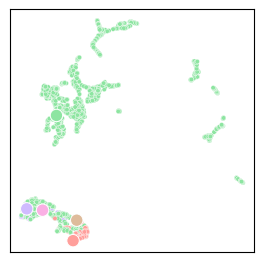

In [4]:
method = 'umap'
data_file = 'data/with_linker/wl_dit.dat'
df, distance_matrix = parse_rmsd_matrix(data_file = data_file, frame_num = 2000)
coords = reduce_rmsd_matrix(distance_matrix, method = method)
log_file = 'data/with_linker/cluster.log'
cluster_result = parse_gromos_cluster_log(log_file)
center_index = [137500, 1000, 38700, 17400, 39500] # according to the cluster log
plot_df, center_df, hue_order = add_cluster_col(df, cluster_result, center_index = center_index, frame_num = 2000)
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wl_analysis_legend', legend = False)

d:\miniconda3\envs\plot\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\jianq\AppData\Local\Temp\ipykernel_32928\675639832.py:89: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  for i in members_list:plot_df.loc[f'{i}','cluster'] = f'{cl_id}'
C:\Users\jianq\AppData\Local\Temp\ipykernel_32928\675639832.py:122: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_32928\675639832.py:123: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  scatter1 = sns.scatterplot(cent

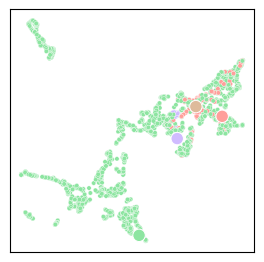

In [5]:
method = 'umap'
data_file = 'data/without_linker/wol_dit.dat'
df, distance_matrix = parse_rmsd_matrix(data_file = data_file, frame_num = 2000)
coords = reduce_rmsd_matrix(distance_matrix, method = method)
log_file = 'data/without_linker/cluster.log'
cluster_result = parse_gromos_cluster_log(log_file)
center_index = [167600, 57100, 40200, 63400]
plot_df, center_df, hue_order = add_cluster_col(df, cluster_result, center_index = center_index, frame_num = 2000)
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wol_analysis', legend = False)